In [7]:
import pandas as pd

# INITIAL DATACHECK
df = pd.read_csv("Data/personality_dataset.csv")

# Sample Head of dataset
print(df.head(5))

# Dataset shape and Description
print("\n",df.shape)
print("\n --- Dataset Description --- ")
print(df.describe())
print("-----------------------------")

# Dataset information
print("\n --- Dataset Summary --- ")
print(df.info())
print("-----------------------------")

# Dataset Null Values
print("\n --- Missing Values --- ")
print(df.isnull().sum())
print("-----------------------------")

# Dataset Duplicates
print("\n --- Duplicate Values --- ")
print(df.duplicated().sum())
print("-----------------------------")

# Initial Cleaning before EDA
# Droping Duplicates
df = df.drop_duplicates()
print(df.shape)

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0               4.0         No                      4.0            6.0   
1               9.0        Yes                      0.0            0.0   
2               9.0        Yes                      1.0            2.0   
3               0.0         No                      6.0            7.0   
4               3.0         No                      9.0            4.0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                 13.0             5.0   Extrovert  
1                       Yes                  0.0             3.0   Introvert  
2                       Yes                  5.0             2.0   Introvert  
3                        No                 14.0             8.0   Extrovert  
4                        No                  8.0             5.0   Extrovert  

 (2900, 8)

 --- Dataset Description --- 
       Time_spent_Alone  Social_event_

# Exploratory Data Analysis

## Class Imbalance


 --- CLASS IMBALANCE --- 
Personality
Extrovert    1417
Introvert    1095
Name: count, dtype: int64
Percentages:
Personality
Extrovert    56.41
Introvert    43.59
Name: count, dtype: float64


[]

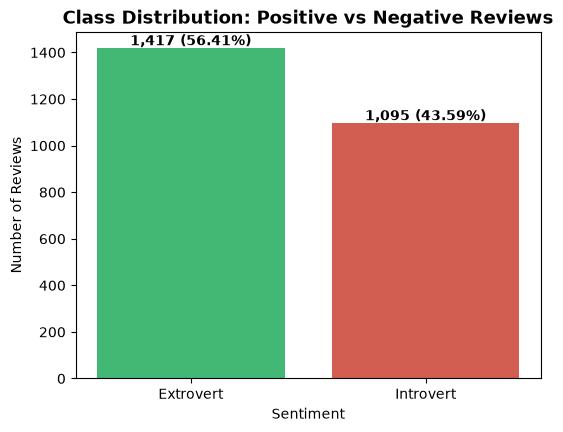

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

''' --- CLASS IMBALANCE --- '''

print("\n"+"=" * 70)
print(" --- CLASS IMBALANCE --- ")
print("=" * 70)
counts = df["Personality"].value_counts()
pct = (counts / counts.sum() * 100).round(2)
print(counts)
print(f"Percentages:\n{pct}")

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.barplot(
    x=counts.index, y=counts.values,
    hue=counts.index, legend=False,
    palette={"Extrovert": "#2ecc71", "Introvert": "#e74c3c"}, ax=ax,
)
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, f"{v:,} ({pct.iloc[i]}%)",
            ha="center", fontweight="bold")
ax.set_title("Class Distribution: Positive vs Negative Reviews", fontsize=13, fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
plt.plot()


## Numerical Features Distribution

[]

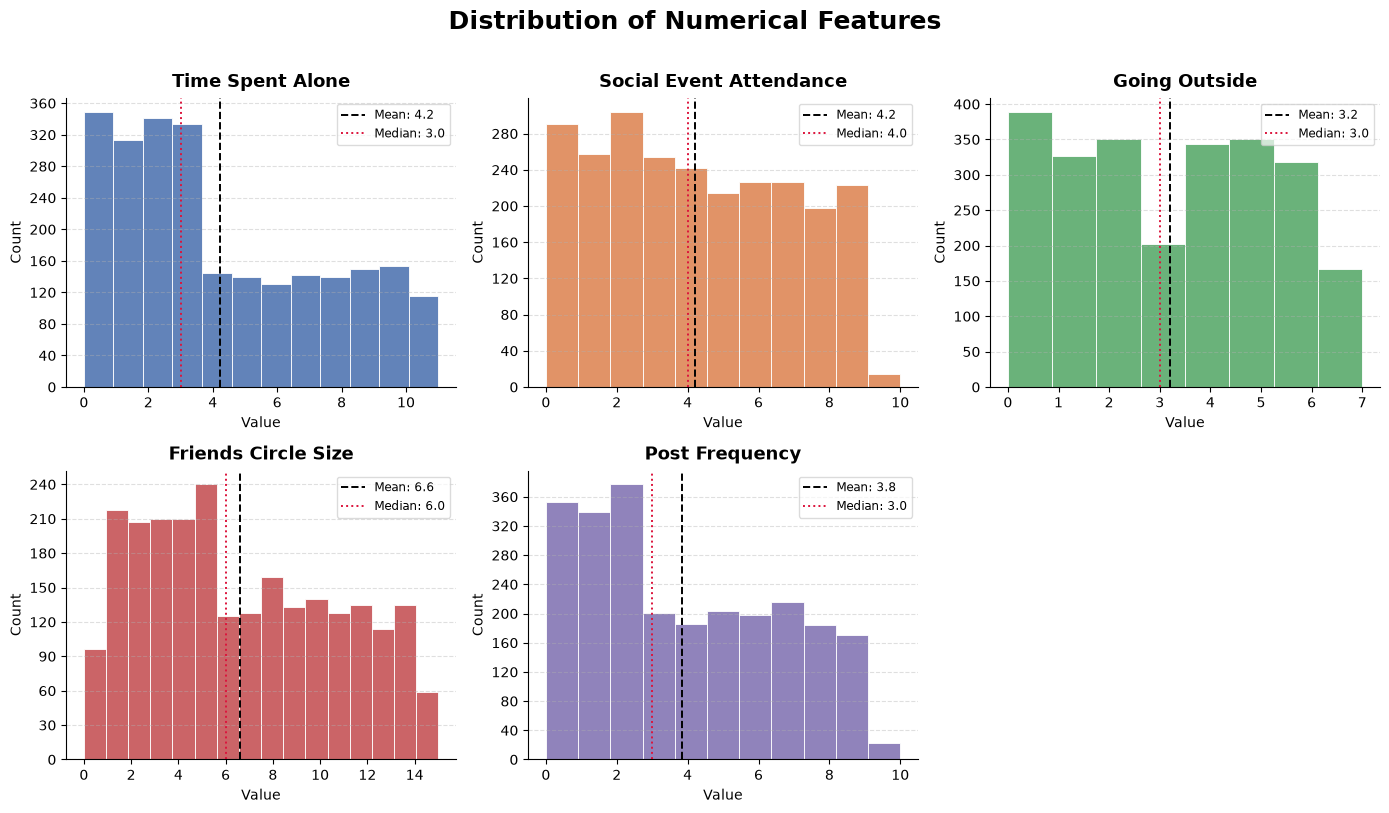

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Define the 5 numerical features
numerical_features = [
    "Time_spent_Alone",
    "Social_event_attendance",
    "Going_outside",
    "Friends_circle_size",
    "Post_frequency"
]

# Clean display names
display_names = {
    "Time_spent_Alone":        "Time Spent Alone",
    "Social_event_attendance": "Social Event Attendance",
    "Going_outside":           "Going Outside",
    "Friends_circle_size":     "Friends Circle Size",
    "Post_frequency":          "Post Frequency"
}

# Color palette
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

# --- Figure setup ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribution of Numerical Features", fontsize=18, fontweight="bold", y=1.01)

axes_flat = axes.flatten()

for i, (col, color) in enumerate(zip(numerical_features, colors)):
    ax = axes_flat[i]
    data = df[col]

    n_bins = int(data.nunique())

    ax.hist(data, bins=n_bins, color=color, edgecolor="white",
            linewidth=0.7, alpha=0.88)

    # Mean & median reference lines
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color="black",  linestyle="--", linewidth=1.4,
               label=f"Mean: {mean_val:.1f}")
    ax.axvline(median_val, color="crimson", linestyle=":",  linewidth=1.4,
               label=f"Median: {median_val:.1f}")

    ax.set_title(display_names[col], fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Value", fontsize=10)
    ax.set_ylabel("Count",  fontsize=10)
    ax.legend(fontsize=8.5, framealpha=0.7)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# Hide the unused 6th subplot
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.plot()

## Numerical Feature Outlier Analysis

[]

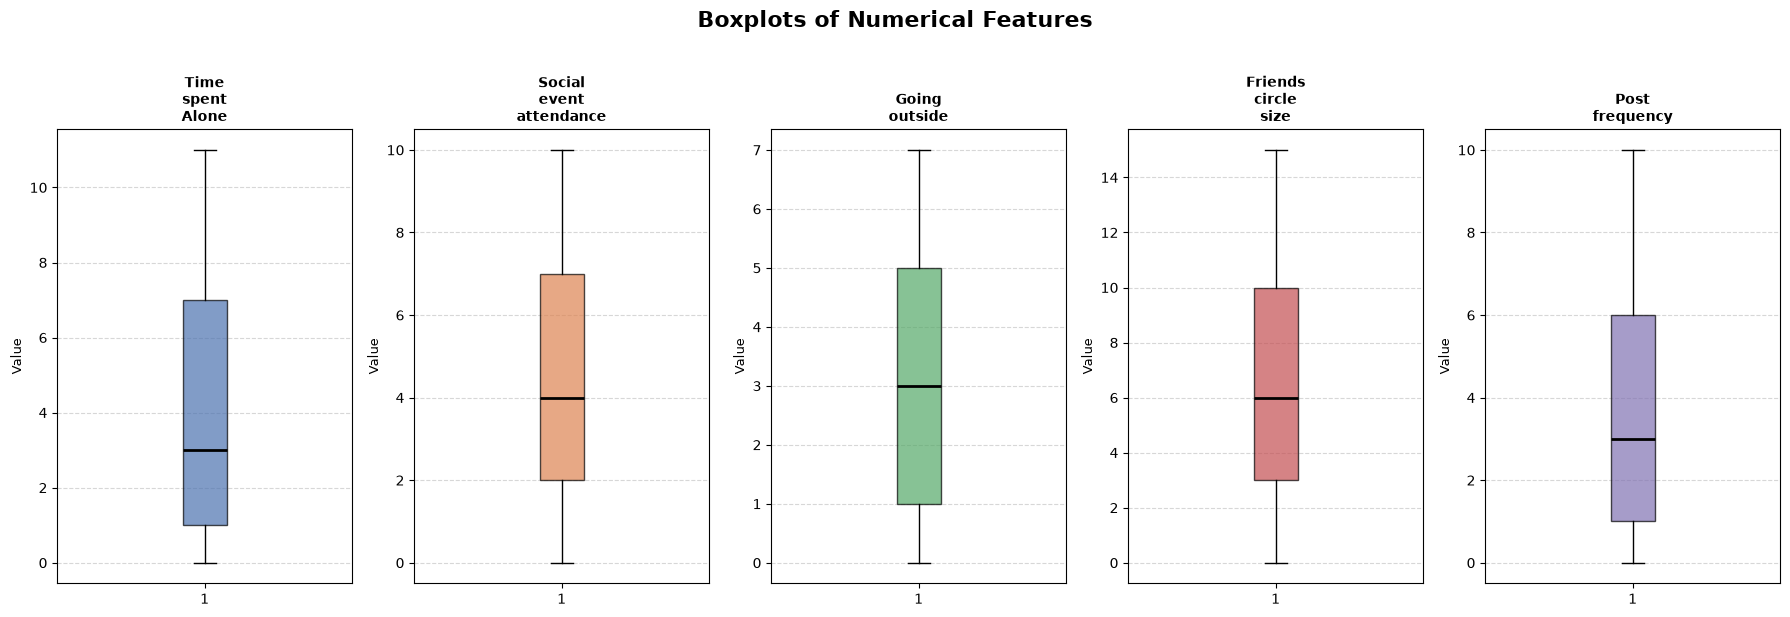

In [37]:
# Define the 5 numerical features
numerical_features = [
    'Time_spent_Alone',
    'Social_event_attendance',
    'Going_outside',
    'Friends_circle_size',
    'Post_frequency'
]

# Create figure with 5 subplots in a single row
fig, axes = plt.subplots(1, 5, figsize=(18, 6))
fig.suptitle('Boxplots of Numerical Features', fontsize=16, fontweight='bold', y=1.02)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for ax, feature, color in zip(axes, numerical_features, colors):
    ax.boxplot(df[feature].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1),)

    ax.set_title(feature.replace('_', '\n'), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.plot()

## Categorical Feature Distribution

[]

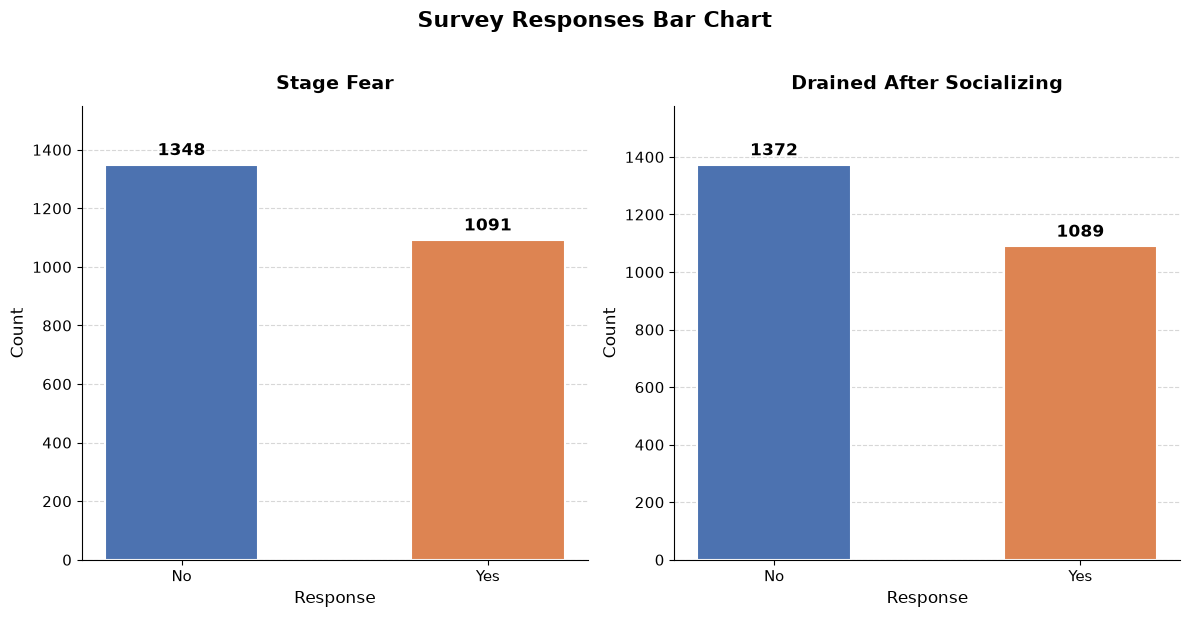

In [40]:
# Count values for each column
stage_fear_counts = df['Stage_fear'].value_counts()
drained_counts = df['Drained_after_socializing'].value_counts()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Survey Responses Bar Chart', fontsize=16, fontweight='bold', y=1.02)

# Stage Fear
colors_sf = ['#4C72B0', '#DD8452']
bars1 = axes[0].bar(stage_fear_counts.index, stage_fear_counts.values,
                    color=colors_sf, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Stage Fear', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Response', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_ylim(0, stage_fear_counts.max() * 1.15)

# Add value labels on top of bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 20,
                 f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Drained After Socializing
colors_dr = ['#4C72B0', '#DD8452']
bars2 = axes[1].bar(drained_counts.index, drained_counts.values,
                    color=colors_dr, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Drained After Socializing', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Response', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_ylim(0, drained_counts.max() * 1.15)

# Add value labels on top of bars
for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, height + 20,
                 f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Style both axes
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=11)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.plot()